In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [25]:
# To facilitate downloading data from Kaggle, we can install this python package
!pip install kagglehub

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/air-quality-and-health-impact-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'air-quality-and-health-impact-dataset' dataset.
Path to dataset files: /kaggle/input/air-quality-and-health-impact-dataset


In [27]:
os.listdir(path)

['air_quality_health_impact_data.csv']

In [28]:
csv_path = os.path.join(path, "air_quality_health_impact_data.csv")

In [29]:
df = pd.read_csv(csv_path)
print(df.head())

   RecordID         AQI        PM10       PM2_5         NO2        SO2  \
0         1  187.270059  295.853039   13.038560    6.639263  66.161150   
1         2  475.357153  246.254703    9.984497   16.318326  90.499523   
2         3  365.996971   84.443191   23.111340   96.317811  17.875850   
3         4  299.329242   21.020609   14.273403   81.234403  48.323616   
4         5   78.009320   16.987667  152.111623  121.235461  90.866167   

           O3  Temperature   Humidity  WindSpeed  RespiratoryCases  \
0   54.624280     5.150335  84.424344   6.137755                 7   
1  169.621728     1.543378  46.851415   4.521422                10   
2    9.006794     1.169483  17.806977  11.157384                13   
3   93.161033    21.925276  99.473373  15.302500                 8   
4  241.795138     9.217517  24.906837  14.534733                 9   

   CardiovascularCases  HospitalAdmissions  HealthImpactScore  \
0                    5                   1          97.244041   
1   

In [30]:
print("NaN counts per column:")
print(df.isna().sum())

NaN counts per column:
RecordID               0
AQI                    0
PM10                   0
PM2_5                  0
NO2                    0
SO2                    0
O3                     0
Temperature            0
Humidity               0
WindSpeed              0
RespiratoryCases       0
CardiovascularCases    0
HospitalAdmissions     0
HealthImpactScore      0
HealthImpactClass      0
dtype: int64


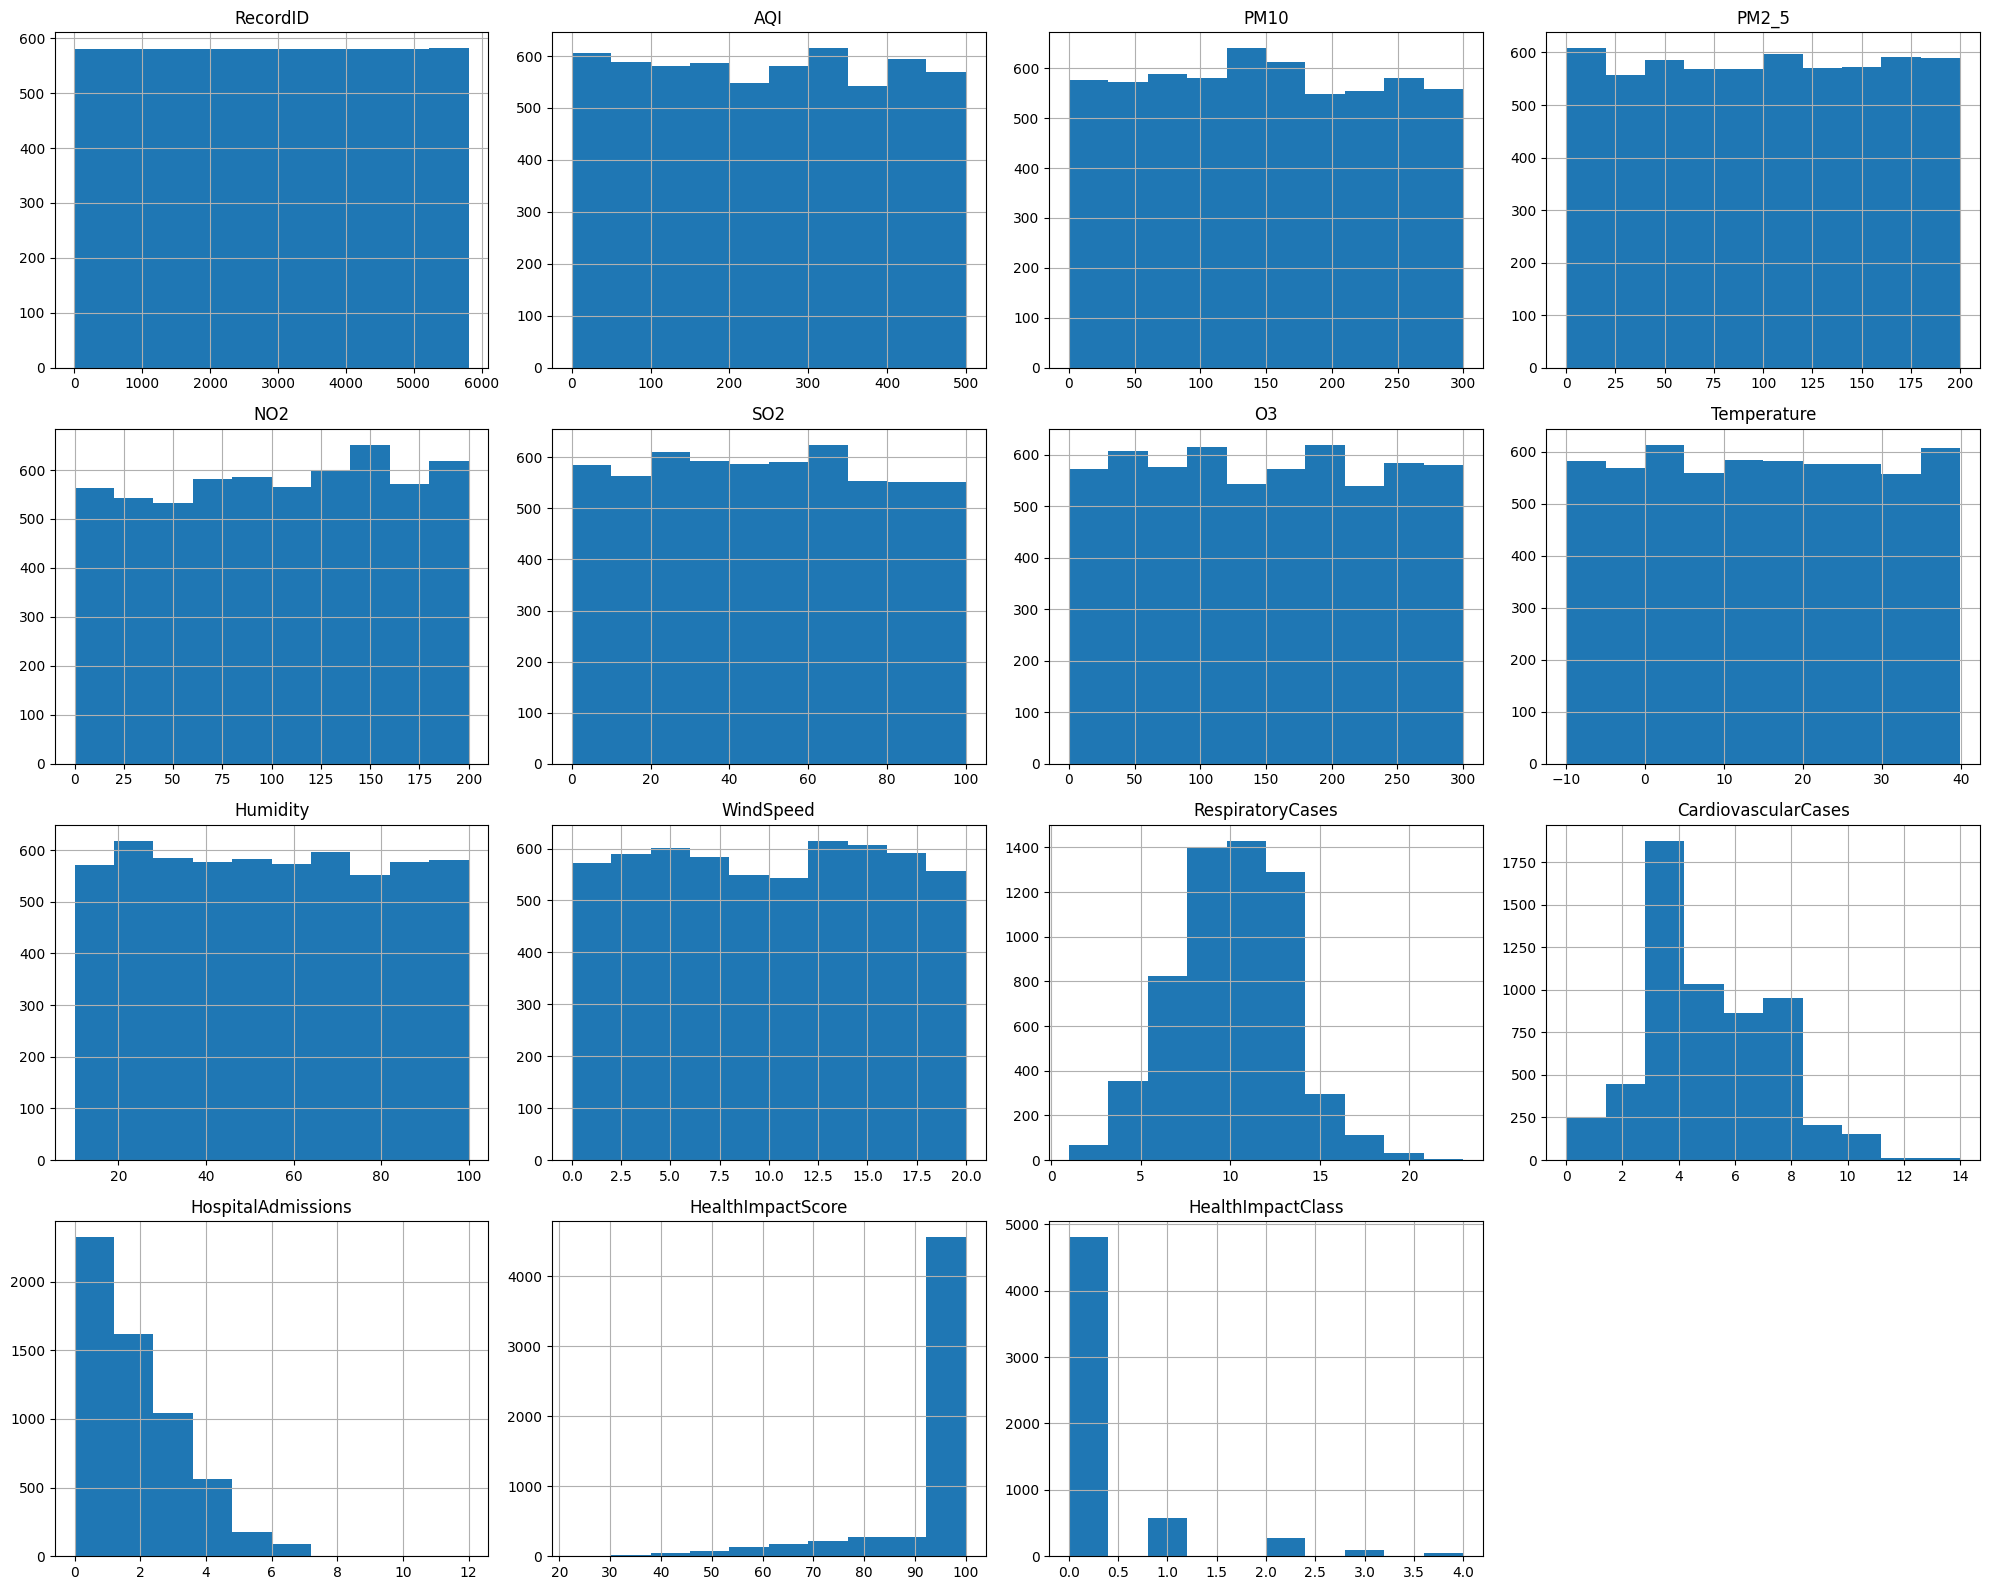

In [31]:
df.hist(figsize=(20, 16))
plt.tight_layout()
plt.show()

In [32]:
y_classification = df["HealthImpactClass"].to_numpy()
y_regression = df["HealthImpactScore"].to_numpy()

In [33]:
print("Class balance (HealthImpactClass):")
print(df["HealthImpactClass"].value_counts())

Class balance (HealthImpactClass):
HealthImpactClass
0.0    4808
1.0     579
2.0     273
3.0      95
4.0      56
Name: count, dtype: int64


In [34]:
feature_columns = [
    "AQI", "PM10", "PM2_5", "NO2", "SO2", "O3",
    "Temperature", "Humidity", "WindSpeed",
]
features = df[feature_columns].to_numpy()

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
feature_names = [
    "AQI", "PM10", "PM2_5", "NO2", "SO2", "O3",
    "Temperature", "Humidity", "WindSpeed",
]

In [37]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [38]:
from sklearn.model_selection import train_test_split

In [44]:
classnames = ["Very High", "High", "Moderate", "Low", "Very Low"]

In [39]:
(
    X_train, X_temp,
    y_classification_train, y_classification_temp,
    y_regression_train, y_regression_temp,
) = train_test_split(
    X, y_classification, y_regression,
    test_size=0.2, random_state=18, stratify=y_classification,
)

(
    X_val, X_test,
    y_classification_val, y_classification_test,
    y_regression_val, y_regression_test,
) = train_test_split(
    X_temp, y_classification_temp, y_regression_temp,
    test_size=0.5, random_state=18, stratify=y_classification_temp,
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 4648
Validation size: 581
Test size: 582


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE

In [41]:
rf_classifier = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    class_weight="balanced",
    random_state=18,
)
rf_classifier.fit(X_train, y_classification_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=120,
                       random_state=18)

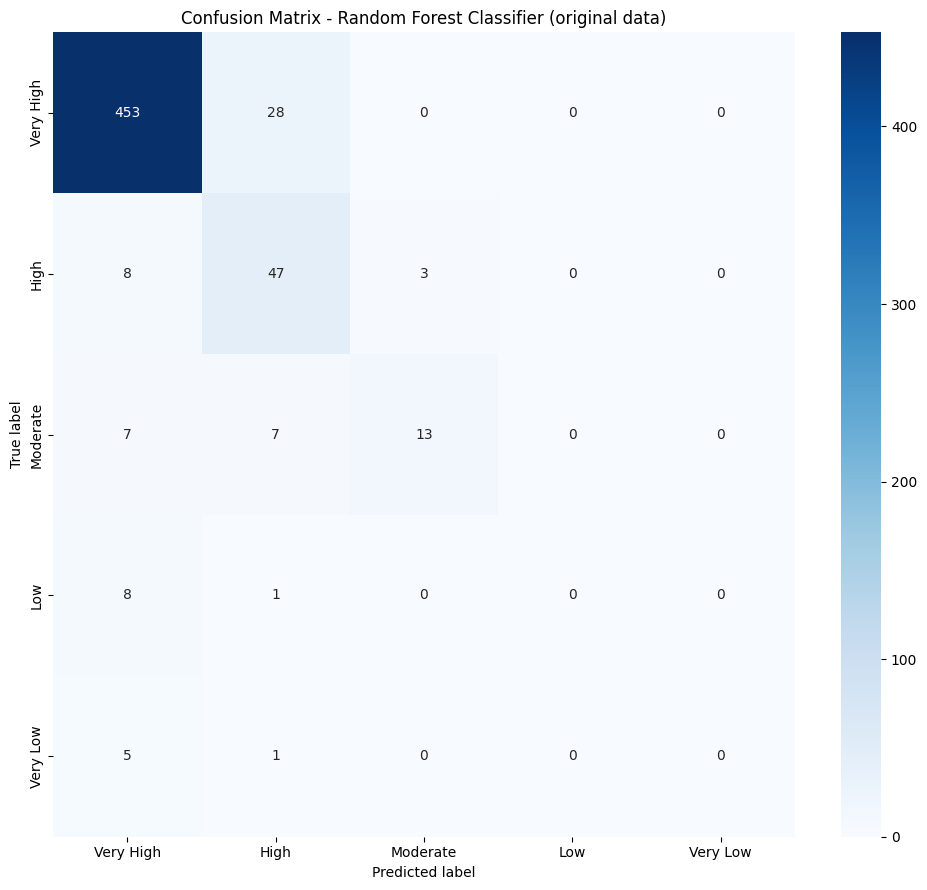

In [45]:
y_val_pred = rf_classifier.predict(X_val)
cm = confusion_matrix(y_classification_val, y_val_pred)

plt.figure(figsize=(10, 9))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=classnames, yticklabels=classnames,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Random Forest Classifier (original data)")
plt.tight_layout()
plt.show()

In [46]:
X_resampled, y_resampled = SMOTE(random_state=18).fit_resample(
    X_train, y_classification_train
)

In [47]:
rf_classifier_smote = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    class_weight="balanced",
    random_state=18,
)
rf_classifier_smote.fit(X_resampled, y_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=120,
                       random_state=18)

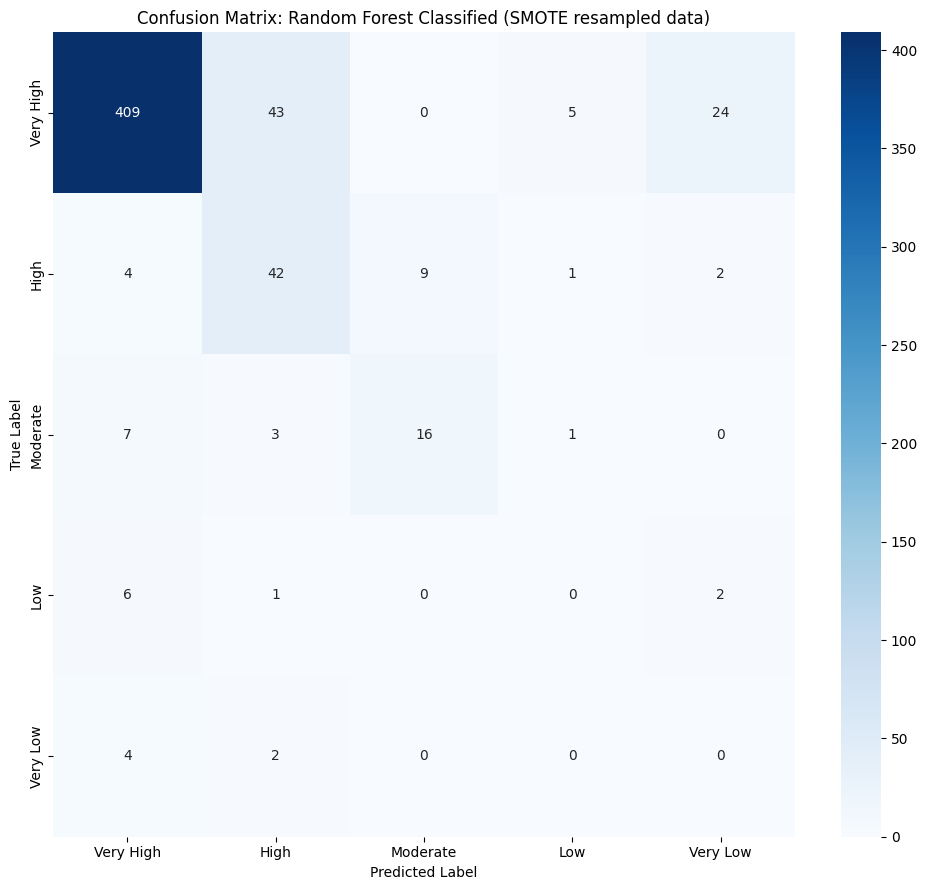

In [48]:
y_val_pred_smote = rf_classifier_smote.predict(X_val)
cm_smote = confusion_matrix(y_classification_val, y_val_pred_smote)

plt.figure(figsize=(10, 9))
sns.heatmap(
    cm_smote, annot=True, fmt="d", cmap="Blues",
    xticklabels=classnames, yticklabels=classnames,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Random Forest Classified (SMOTE resampled data)")
plt.tight_layout()
plt.show()

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [50]:
rf_regressor = RandomForestRegressor(
    n_estimators=120,
    max_depth=10,
    random_state=18,
)
rf_regressor.fit(X_train, y_regression_train)

RandomForestRegressor(max_depth=10, n_estimators=120, random_state=18)

In [51]:
y_reg_val_pred = rf_regressor.predict(X_val)
r2 = r2_score(y_regression_val, y_reg_val_pred)
print(f"R^2 (coefficient of determination) on validation set: {r2:.4f}")

R^2 (coefficient of determination) on validation set: 0.9419


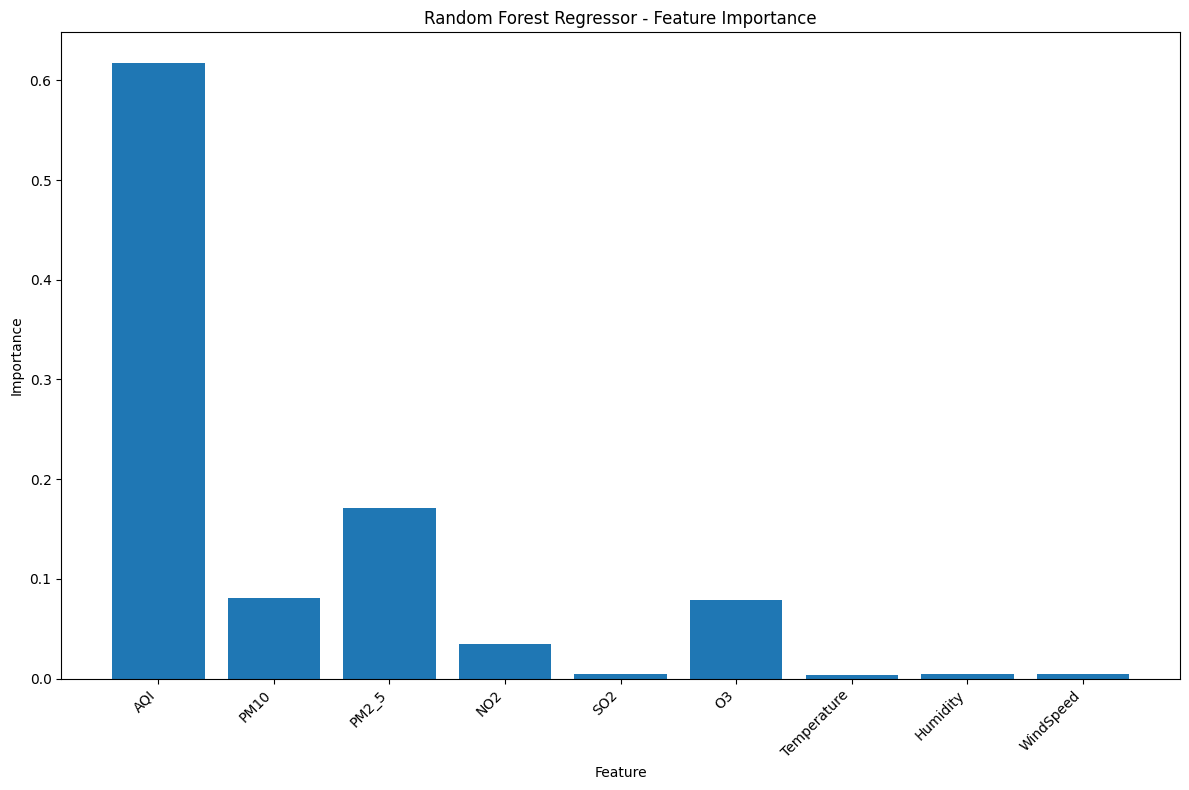

In [52]:
importances = rf_regressor.feature_importances_

plt.figure(figsize=(12, 8))
plt.bar(feature_names, importances)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Regressor - Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [53]:
top4_idx = np.argsort(importances)[::-1][:4]
top4_features = [feature_names[i] for i in top4_idx]
print("Top 4 most important features:", top4_features)

Top 4 most important features: ['AQI', 'PM2_5', 'PM10', 'O3']
